# IMPORT LIBRARY

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import cv2, os, shutil, random
import pathlib

print("TF Version:", tf.__version__)

TF Version: 2.21.0


# Extract Dataset

In [4]:
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dataset_dir = "dataset_ayam"

# Labelling

In [5]:
import os, shutil

BASE_DIR = "dataset_ayam"
CLASSES  = ["cocci", "healthy", "ncd", "salmo"]

for split in ["train", "valid", "test"]:
    split_path = os.path.join(BASE_DIR, split)

    # Buat subfolder per kelas
    for kelas in CLASSES:
        os.makedirs(os.path.join(split_path, kelas), exist_ok=True)

    # Pindahkan gambar ke subfolder yang sesuai
    for fname in os.listdir(split_path):
        fpath = os.path.join(split_path, fname)
        if not os.path.isfile(fpath): continue

        for kelas in CLASSES:
            if fname.startswith(kelas):
                shutil.move(fpath, os.path.join(split_path, kelas, fname))
                break

# Verifikasi
print("=" * 45)
for split in ["train", "valid", "test"]:
    print(f"\n {split}:")
    for kelas in CLASSES:
        path = os.path.join(BASE_DIR, split, kelas)
        print(f"   {kelas:<10}: {len(os.listdir(path))} gambar")
print("=" * 45)


 train:
   cocci     : 240 gambar
   healthy   : 240 gambar
   ncd       : 240 gambar
   salmo     : 240 gambar

 valid:
   cocci     : 30 gambar
   healthy   : 30 gambar
   ncd       : 30 gambar
   salmo     : 30 gambar

 test:
   cocci     : 15 gambar
   healthy   : 15 gambar
   ncd       : 15 gambar
   salmo     : 14 gambar


In [6]:
# Konfigurasi
IMG_SIZE   = (180, 180)   # Resize 180x180
CLASSES    = ["cocci", "healthy", "ncd", "salmo"]
SPLITS     = ["train", "valid", "test"]
BASE_DIR   = "dataset_ayam"

# Cek & Labeling - hitung gambar per kelas
print("=" * 50)
print(f"{'LABELING DATASET':^50}")
print("=" * 50)
print(f"{'Split':<10} {'Kelas':<12} {'Jumlah':>8} {'Label ID':>10}")
print("-" * 50)

label_map = {kelas: idx for idx, kelas in enumerate(CLASSES)}

for split in SPLITS:
    for kelas in CLASSES:
        path = os.path.join(BASE_DIR, split, kelas)
        if os.path.exists(path):
            jumlah = len(os.listdir(path))
            print(f"{split:<10} {kelas:<12} {jumlah:>8} {label_map[kelas]:>10}")

print("=" * 50)
print(f"\nLabel Mapping: {label_map}")

                 LABELING DATASET                 
Split      Kelas          Jumlah   Label ID
--------------------------------------------------
train      cocci             240          0
train      healthy           240          1
train      ncd               240          2
train      salmo             240          3
valid      cocci              30          0
valid      healthy            30          1
valid      ncd                30          2
valid      salmo              30          3
test       cocci              15          0
test       healthy            15          1
test       ncd                15          2
test       salmo              14          3

Label Mapping: {'cocci': 0, 'healthy': 1, 'ncd': 2, 'salmo': 3}


# Prepocessing

In [7]:
def load_and_preprocess(base_dir, splits, classes, img_size=(180, 180)):
    """Load gambar, resize 180x180, dan encode label"""
    images, labels = [], []

    for split in splits:
        for kelas in classes:
            folder = os.path.join(base_dir, split, kelas)
            if not os.path.exists(folder):
                continue

            for fname in os.listdir(folder):
                fpath = os.path.join(folder, fname)
                try:
                    # Load & Resize
                    img = cv2.imread(fpath)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, img_size)          # Resize 180x180
                    img = img.astype(np.float32) / 255.0     # Normalisasi [0,1]

                    images.append(img)
                    labels.append(kelas)
                except Exception as e:
                    print(f"Skip {fname}: {e}")

    return np.array(images), np.array(labels)

print("Loading & preprocessing gambar... (tunggu sebentar)")
X, y_raw = load_and_preprocess(BASE_DIR, SPLITS, CLASSES, IMG_SIZE)
print(f"Total gambar loaded : {len(X)}")
print(f"Shape gambar        : {X.shape}")
print(f"Label unik          : {np.unique(y_raw)}")

Loading & preprocessing gambar... (tunggu sebentar)


Total gambar loaded : 1139
Shape gambar        : (1139, 180, 180, 3)
Label unik          : ['cocci' 'healthy' 'ncd' 'salmo']


# Encoding Label

In [8]:
# Label Encoding → Integer
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

print("=" * 40)
print("LABEL ENCODING")
print("=" * 40)
for kelas, idx in zip(le.classes_, range(len(le.classes_))):
    print(f"  {kelas:<12} → {idx}")
print("=" * 40)
print(f"\nContoh 5 label: {y_raw[:5]}")
print(f"Setelah encode: {y_encoded[:5]}")

# One-hot encoding untuk training
from tensorflow.keras.utils import to_categorical
NUM_CLASSES = len(CLASSES)
y_onehot = to_categorical(y_encoded, num_classes=NUM_CLASSES)
print(f"\n One-hot shape: {y_onehot.shape}")
print(f"Contoh: {y_raw[0]} → {y_onehot[0]}")

LABEL ENCODING
  cocci        → 0
  healthy      → 1
  ncd          → 2
  salmo        → 3

Contoh 5 label: ['cocci' 'cocci' 'cocci' 'cocci' 'cocci']
Setelah encode: [0 0 0 0 0]

 One-hot shape: (1139, 4)
Contoh: cocci → [1. 0. 0. 0.]


# Pembagian Dataset Train & Test

PEMBAGIAN DATASET
  Train      :   797 gambar (70.0%)
  Validation :   171 gambar (15.0%)
  Test       :   171 gambar (15.0%)
  Total      :  1139 gambar


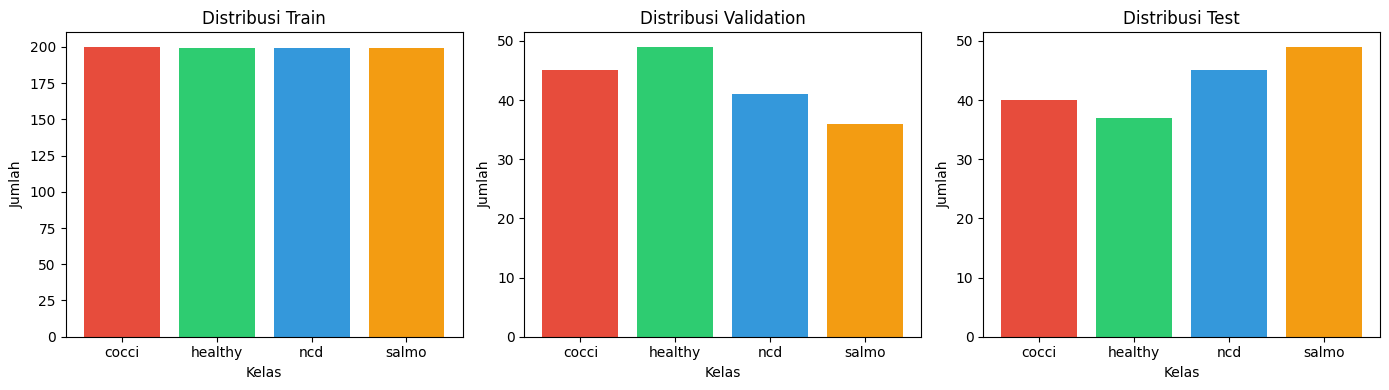

In [9]:
# Split Train / Validation / Test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_onehot, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("=" * 40)
print("PEMBAGIAN DATASET")
print("=" * 40)
print(f"  Train      : {len(X_train):>5} gambar ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation : {len(X_val):>5} gambar ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test       : {len(X_test):>5} gambar ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Total      : {len(X):>5} gambar")
print("=" * 40)

# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (data, nama) in zip(axes, [
    (y_train, "Train"), (y_val, "Validation"), (y_test, "Test")
]):
    counts = np.argmax(data, axis=1)
    ax.bar(CLASSES, [np.sum(counts==i) for i in range(NUM_CLASSES)],
           color=['#e74c3c','#2ecc71','#3498db','#f39c12'])
    ax.set_title(f"Distribusi {nama}")
    ax.set_xlabel("Kelas")
    ax.set_ylabel("Jumlah")

plt.tight_layout()
plt.show()

# Visualisasi Sample Hasil Prepocessing

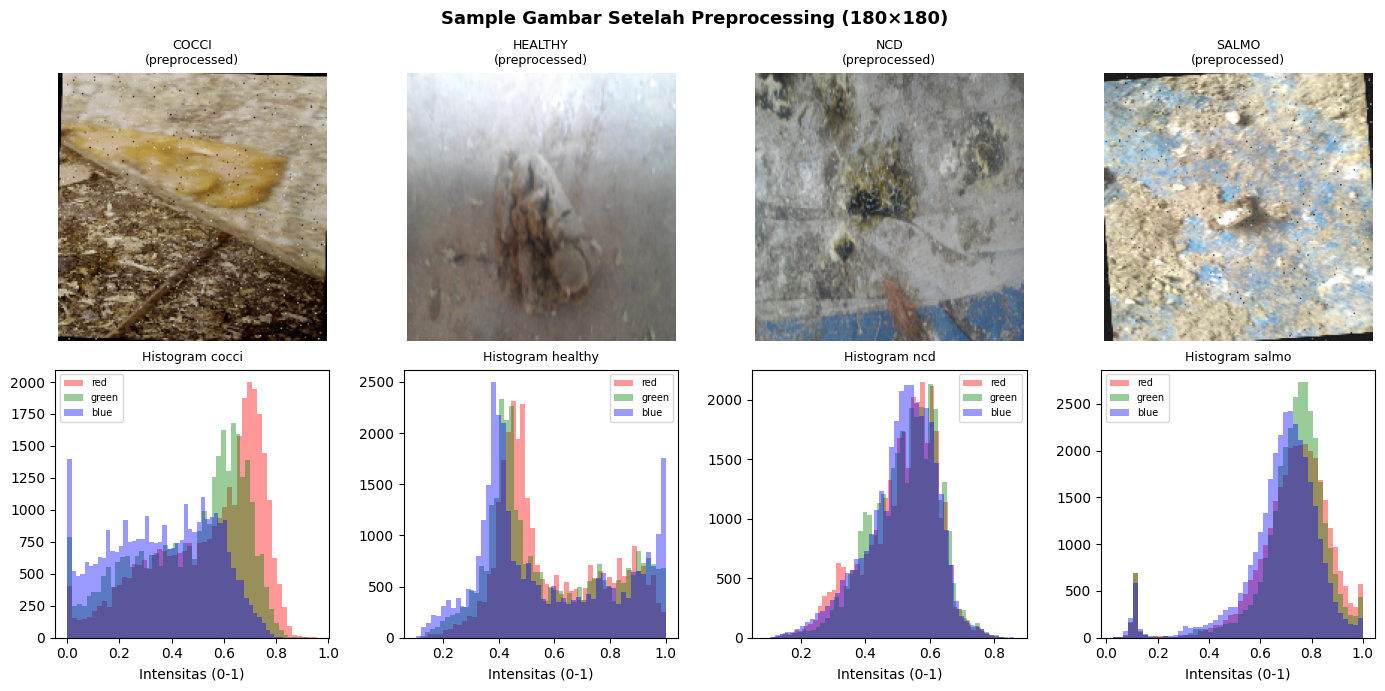

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Sample Gambar Setelah Preprocessing (180×180)",
             fontsize=13, fontweight='bold')

for i, kelas in enumerate(CLASSES):
    # Ambil index gambar kelas ini dari train
    idx_kelas = np.where(np.argmax(y_train, axis=1) == i)[0]
    idx = random.choice(idx_kelas)

    # Gambar asli (sudah preprocessed)
    axes[0][i].imshow(X_train[idx])
    axes[0][i].set_title(f"{kelas.upper()}\n(preprocessed)", fontsize=9)
    axes[0][i].axis('off')

    # Histogram warna
    colors_hist = ['red', 'green', 'blue']
    for c, col in enumerate(colors_hist):
        axes[1][i].hist(X_train[idx][:,:,c].flatten(),
                        bins=50, color=col, alpha=0.4, label=col)
    axes[1][i].set_title(f"Histogram {kelas}", fontsize=9)
    axes[1][i].set_xlabel("Intensitas (0-1)")
    axes[1][i].legend(fontsize=7)

plt.tight_layout()
plt.show()

# Training Model

In [11]:
base_model = MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model siap!")
model.summary()

C:\Users\kurni\AppData\Local\Temp\ipykernel_15132\2130463354.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model siap!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.6813 - loss: 0.7970 - val_accuracy: 0.8947 - val_loss: 0.2957 - learning_rate: 0.0010
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8908 - loss: 0.3101 - val_accuracy: 0.9181 - val_loss: 0.2006 - learning_rate: 0.0010
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9360 - loss: 0.2029 - val_accuracy: 0.9532 - val_loss: 0.1723 - learning_rate: 0.0010
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 967ms/step - accuracy: 0.9435 - loss: 0.1612 - val_accuracy: 0.9591 - val_loss: 0.1429 - learning_rate: 0.0010
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9636 - loss: 0.1258 - val_accuracy: 0.9591 - val_loss: 0.1421 - learning_rate: 0.0010
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9812 - loss: 0.0847 - val_accuracy: 0.9591 - val_loss: 0.1297 - learning_rate: 0.0010
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9787 - loss: 0.0740 - val_accurac

KeyboardInterrupt: 

# Evaluasi dan Confusion Matrix

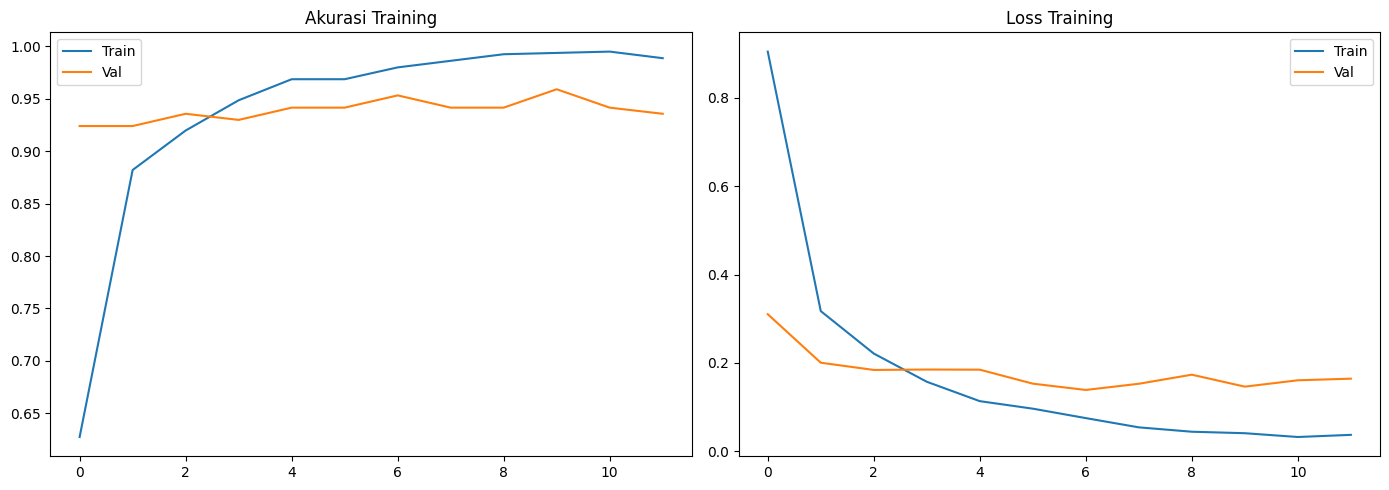

6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 968ms/step
              precision    recall  f1-score   support

       cocci       0.95      0.97      0.96        40
     healthy       0.87      0.89      0.88        37
         ncd       1.00      0.91      0.95        45
       salmo       0.88      0.92      0.90        49

    accuracy                           0.92       171
   macro avg       0.93      0.92      0.92       171
weighted avg       0.93      0.92      0.92       171



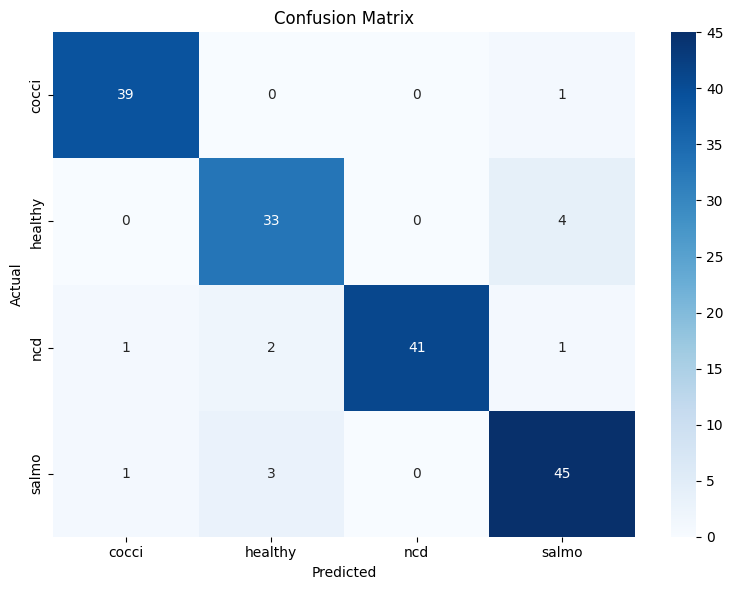


Test Accuracy: 92.40%


In [ ]:
# Plot akurasi & loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Akurasi Training'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss Training'); axes[1].legend()
plt.tight_layout(); plt.show()

# Prediksi
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc*100:.2f}%")

# Pengujian Model

In [ ]:
# Mapping label ID → nama penyakit lengkap
DISEASE_MAP = {
    "cocci"  : "Coccidiosis",
    "healthy": "Healthy",
    "ncd"    : "Newcastle Disease",
    "salmo"  : "Salmonella"
}

def predict_image(img_path, model, le, img_size=(180, 180)):
    """Prediksi 1 gambar dan tampilkan hasilnya"""
    # Load & Preprocess
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, img_size)
    img_normalized = img_resized.astype(np.float32) / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)  # (1, 180, 180, 3)

    # Prediksi
    pred_prob   = model.predict(img_input, verbose=0)
    pred_idx    = np.argmax(pred_prob)
    pred_label  = le.inverse_transform([pred_idx])[0]
    pred_name   = DISEASE_MAP[pred_label]
    confidence  = pred_prob[0][pred_idx] * 100

    return pred_label, pred_name, confidence, pred_prob[0], img

print("Fungsi prediksi siap!")

Fungsi prediksi siap!


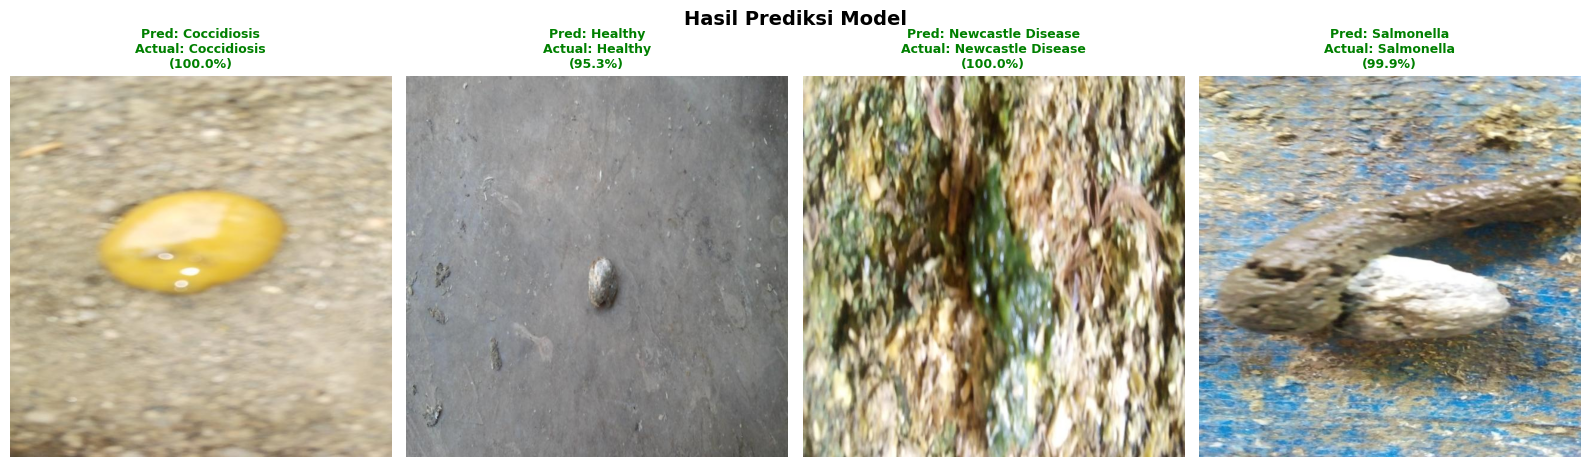

In [ ]:
# Ambil beberapa gambar dari test set dan prediksi
BASE_TEST = "dataset_ayam/test"
N_SAMPLE  = 4  # jumlah gambar yang ditampilkan

fig, axes = plt.subplots(1, N_SAMPLE, figsize=(16, 5))
fig.suptitle("Hasil Prediksi Model", fontsize=14, fontweight='bold')

sample_paths = []
sample_true  = []

# Ambil 1 gambar random per kelas
for kelas in CLASSES:
    folder = os.path.join(BASE_TEST, kelas)
    if os.path.exists(folder):
        fname = random.choice(os.listdir(folder))
        sample_paths.append(os.path.join(folder, fname))
        sample_true.append(kelas)

for i, (img_path, true_label) in enumerate(zip(sample_paths, sample_true)):
    pred_label, pred_name, confidence, _, img = predict_image(img_path, model, le)
    true_name = DISEASE_MAP[true_label]

    is_correct = pred_label == true_label
    color = 'green' if is_correct else 'red'

    axes[i].imshow(img)
    axes[i].set_title(
        f"Pred: {pred_name}\nActual: {true_name}\n({confidence:.1f}%)",
        fontsize=9, fontweight='bold', color=color
    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Silakan upload gambar feses ayam...


Saving Screenshot 2026-04-28 224729.png to Screenshot 2026-04-28 224729.png


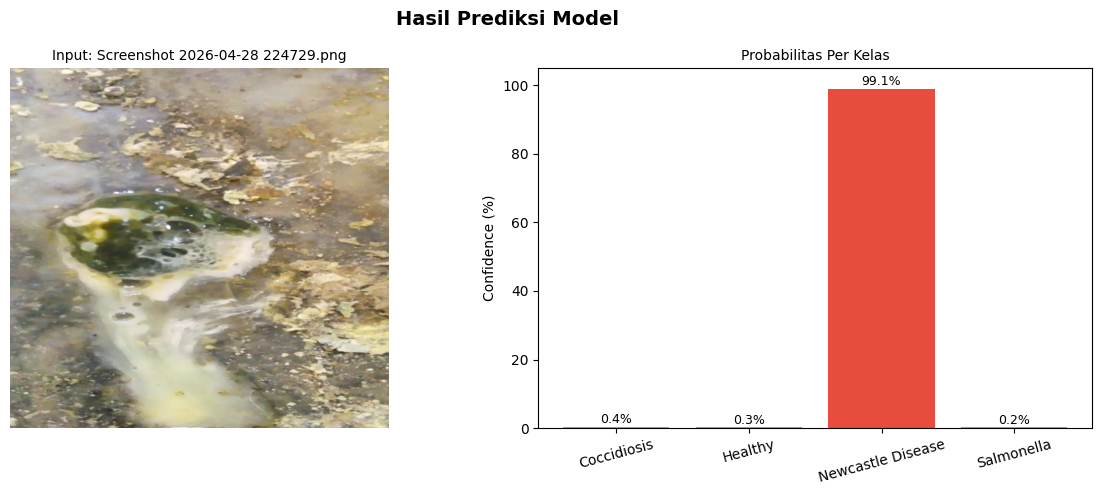


Image   : Screenshot 2026-04-28 224729.png
One-hot : [np.float32(0.0), np.float32(0.0), np.float32(0.99), np.float32(0.0)]
Pred ID : 2
-----------------------------------
Predicted : Newcastle Disease
Confidence: 99.08%


In [ ]:
print("Silakan upload gambar feses ayam...")
uploaded_img = files.upload()

for fname, _ in uploaded_img.items():
    pred_label, pred_name, confidence, all_probs, img = predict_image(
        fname, model, le
    )

    # Tampilkan hasil
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Hasil Prediksi Model", fontsize=14, fontweight='bold')

    # Gambar input
    axes[0].imshow(img)
    axes[0].set_title(f"Input: {fname}", fontsize=10)
    axes[0].axis('off')

    # Bar chart probabilitas semua kelas
    colors_bar = ['#e74c3c' if c == pred_label else '#95a5a6' for c in CLASSES]
    bars = axes[1].bar(
        [DISEASE_MAP[c] for c in CLASSES],
        all_probs * 100,
        color=colors_bar
    )
    axes[1].set_title("Probabilitas Per Kelas", fontsize=10)
    axes[1].set_ylabel("Confidence (%)")
    axes[1].set_ylim(0, 105)
    axes[1].tick_params(axis='x', rotation=15)

    # Tambah nilai di atas bar
    for bar, prob in zip(bars, all_probs):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1,
                     f"{prob*100:.1f}%", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Output teks (seperti Gambar 3.9 & 3.10)
    print(f"\nImage   : {fname}")
    print(f"One-hot : {[round(p, 2) for p in all_probs]}")
    print(f"Pred ID : {np.argmax(all_probs)}")
    print("-" * 35)
    print(f"Predicted : {pred_name}")
    print(f"Confidence: {confidence:.2f}%")